# Exploration 05: 영화 리뷰 텍스트 감정분석하기

In [13]:
import pandas
import konlpy
import gensim
import torch

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.3.0
0.6.0
4.3.2


## STEP 1: 데이터 준비와 확인

In [2]:
import pandas as pd
import os

# 데이터를 읽어봅시다.
train_data = pd.read_table(os.getenv("HOME") + '/work/AIFFEL_quest_rs/Exploration/Ex05/data/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/work/AIFFEL_quest_rs/Exploration/Ex05/data/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## STEP 2: 데이터로더 구성

In [3]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [4]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [5]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

In [10]:
### 데이터 체크 하기
# 데이터 개수 확인
print('훈련 데이터:', len(X_train))
print('테스트 데이터:', len(X_test))

# 라벨 분포 확인
print('\n긍정(1):', sum(y_train), '부정(0):', len(y_train)-sum(y_train))

# 인코딩된 샘플 확인
print('\n인코딩된 문장:', X_train[0])

# 디코딩해서 원문 확인
print('디코딩된 문장:', ' '.join([index_to_word[i] for i in X_train[0]]))

훈련 데이터: 146182
테스트 데이터: 49157

긍정(1): 72840 부정(0): 73342

인코딩된 문장: [32, 74, 939, 4, 4, 39, 229, 20, 33, 747]
디코딩된 문장: 아 더 빙 . . 진짜 짜증 나 네요 목소리


---

## STEP 3: 모델 구성을 위한 데이터 분석 및 가공
- 데이터셋 내 문장 길이 분포
- 적절한 최대 문장 길이 지정
- torch.nn.utils.rnn.pad_sequence을 활용한 패딩 추가

### 1) 데이터셋 내 문장 길이 분포

In [11]:
total_data_text = list(X_train) + list(X_test)
# 텍스트데이터 문장길이의 리스트를 생성한 후
num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)
# 문장길이의 평균값, 최대값, 표준편차를 계산해 본다.
print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

# 예를들어, 최대 길이를 (평균 + 2*표준편차)로 한다면,
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print('pad_sequences maxlen : ', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens)}%가 maxlen 설정값 이내에 포함됩니다. ')

문장길이 평균 :  15.971029850669861
문장길이 최대 :  116
문장길이 표준편차 :  12.844117035625121
pad_sequences maxlen :  41
전체 문장의 0.9342629991962691%가 maxlen 설정값 이내에 포함됩니다. 


### 2) torch.nn.utils.rnn.pad_sequence을 활용한 패딩 추가

In [25]:
# pre로 padding 채우기
def pad_sequences(data, maxlen):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = [0] * (maxlen - len(sentence)) + sentence
        else:
            sentence = sentence[:maxlen]
        padded_data.append(sentence)
    return np.array(padded_data)

x_train_padded = pad_sequences(X_train, maxlen)
x_test_padded = pad_sequences(X_test, maxlen)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

print(x_train_tensor.shape)
print(x_test_tensor.shape)

torch.Size([146182, 41])
torch.Size([49157, 41])


pad_sequences 의 padding 방식은 'pre'로 한다. 마지막 입력이 무의미한 padding으로 채워지는 것은 비효율적이기 때문이다.

---

## STEP 4: 모델 구성 및 validation set 구성
모델 3가지 이상 다양하기 구성하기

### 1) RNN 모델 구성하기

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000    # 어휘 사전의 크기입니다(10,000개의 단어)
word_vector_dim = 16  # 워드 벡터의 차원 수 (변경 가능한 하이퍼파라미터)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.rnn = nn.RNN(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, hn = self.rnn(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

rnn_model = RNNModel(vocab_size, word_vector_dim)
print(rnn_model)

RNNModel(
  (embedding): Embedding(10000, 16)
  (rnn): RNN(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


### 2) LSTM 모델 구성하기

In [20]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

lstm_model = LSTMModel(vocab_size, word_vector_dim)
print(lstm_model)

LSTMModel(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


## 3) 1D CNN 모델 구성하기

In [21]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)  # (batch, channels, seq_len)으로 변환
        x = F.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

cnn_model = CNNModel(vocab_size, word_vector_dim)
print(cnn_model)

CNNModel(
  (embedding): Embedding(10000, 16)
  (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


### 4) Validation set 구성하기

In [24]:
# validation set 20000건 분리
x_val = x_train_tensor[:20000]
y_val = y_train[:20000]

# validation set을 제외한 나머지 훈련 데이터
partial_x_train = x_train_tensor[20000:]
partial_y_train = y_train[20000:]

# 데이터 분리 확인
print('Train:', partial_x_train.shape[0])
print('Validation:', x_val.shape[0])
print('Test:', x_test_tensor.shape[0])

total = partial_x_train.shape[0] + x_val.shape[0] + x_test_tensor.shape[0]
print(f'\nTrain 비율: {partial_x_train.shape[0]/total:.1%}')
print(f'Validation 비율: {x_val.shape[0]/total:.1%}')
print(f'Test 비율: {x_test_tensor.shape[0]/total:.1%}')

Train: 126182
Validation: 20000
Test: 49157

Train 비율: 64.6%
Validation 비율: 10.2%
Test 비율: 25.2%


---
### 데이터 분리

전체 데이터를 Train / Validation / Test로 분리하였다.

- **Train**: 126,182건 (약 65%) - 모델 학습에 사용
- **Validation**: 20,000건 (약 10%) - 학습 중 과적합 모니터링 및 하이퍼파라미터 튜닝에 사용
- **Test**: ~49,157건 (약 25%) - 최종 성능 평가에 사용 

Validation set은 전체 훈련 데이터의 약 13%를 분리하였으며, 너무 적으면 검증 신뢰도가 낮고 너무 크면 학습 데이터가 부족해지므로 20,000건으로 설정하였다.

---

## STEP 5: 모델 훈련 개시

### 모델 학습 설정

공통 학습 함수를 정의하여 3가지 모델(RNN, LSTM, 1D CNN)을 동일한 조건에서 비교한다.

- **Optimizer**: Adam
- **Loss Function**: BCELoss (이진 분류)
- **Batch Size**: 512
- **Epochs**: 30
- **평가 지표**: Loss, Accuracy (Train / Validation)

In [27]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

train_dataset = TensorDataset(partial_x_train, partial_y_train_tensor)
val_dataset = TensorDataset(x_val, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

def train_model(model, epochs=30):
    optimizer = optim.Adam(model.parameters())
    loss_fn = torch.nn.BCELoss()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), labels)
                val_loss += loss.item()
                predicted = (outputs.squeeze() > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} - "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs

### 1) RNN 학습

In [28]:
print("=== RNN 모델 ===")
rnn_model = RNNModel(vocab_size, word_vector_dim)
rnn_results = train_model(rnn_model, epochs=30)

=== RNN 모델 ===
Epoch 1/30 - Train Loss: 0.6843, Train Acc: 0.5547 - Val Loss: 0.6712, Val Acc: 0.5837
Epoch 2/30 - Train Loss: 0.6452, Train Acc: 0.6265 - Val Loss: 0.6085, Val Acc: 0.6717
Epoch 3/30 - Train Loss: 0.5454, Train Acc: 0.7296 - Val Loss: 0.5017, Val Acc: 0.7641
Epoch 4/30 - Train Loss: 0.4678, Train Acc: 0.7869 - Val Loss: 0.4536, Val Acc: 0.7953
Epoch 5/30 - Train Loss: 0.4251, Train Acc: 0.8124 - Val Loss: 0.4273, Val Acc: 0.8091
Epoch 6/30 - Train Loss: 0.3970, Train Acc: 0.8284 - Val Loss: 0.4094, Val Acc: 0.8181
Epoch 7/30 - Train Loss: 0.3767, Train Acc: 0.8382 - Val Loss: 0.3984, Val Acc: 0.8254
Epoch 8/30 - Train Loss: 0.3614, Train Acc: 0.8463 - Val Loss: 0.3905, Val Acc: 0.8288
Epoch 9/30 - Train Loss: 0.3485, Train Acc: 0.8527 - Val Loss: 0.3845, Val Acc: 0.8329
Epoch 10/30 - Train Loss: 0.3388, Train Acc: 0.8583 - Val Loss: 0.3818, Val Acc: 0.8343
Epoch 11/30 - Train Loss: 0.3292, Train Acc: 0.8628 - Val Loss: 0.3781, Val Acc: 0.8366
Epoch 12/30 - Train Loss: 

### 2) LSTM 학습

In [29]:
print("=== LSTM 모델 ===")
lstm_model = LSTMModel(vocab_size, word_vector_dim)
lstm_results = train_model(lstm_model, epochs=30)

=== LSTM 모델 ===
Epoch 1/30 - Train Loss: 0.6621, Train Acc: 0.5939 - Val Loss: 0.5788, Val Acc: 0.7078
Epoch 2/30 - Train Loss: 0.5149, Train Acc: 0.7533 - Val Loss: 0.4679, Val Acc: 0.7843
Epoch 3/30 - Train Loss: 0.4435, Train Acc: 0.7987 - Val Loss: 0.4230, Val Acc: 0.8088
Epoch 4/30 - Train Loss: 0.4058, Train Acc: 0.8206 - Val Loss: 0.3996, Val Acc: 0.8207
Epoch 5/30 - Train Loss: 0.3812, Train Acc: 0.8340 - Val Loss: 0.3831, Val Acc: 0.8295
Epoch 6/30 - Train Loss: 0.3637, Train Acc: 0.8432 - Val Loss: 0.3741, Val Acc: 0.8329
Epoch 7/30 - Train Loss: 0.3495, Train Acc: 0.8506 - Val Loss: 0.3663, Val Acc: 0.8370
Epoch 8/30 - Train Loss: 0.3382, Train Acc: 0.8575 - Val Loss: 0.3617, Val Acc: 0.8399
Epoch 9/30 - Train Loss: 0.3290, Train Acc: 0.8617 - Val Loss: 0.3592, Val Acc: 0.8413
Epoch 10/30 - Train Loss: 0.3208, Train Acc: 0.8661 - Val Loss: 0.3570, Val Acc: 0.8447
Epoch 11/30 - Train Loss: 0.3136, Train Acc: 0.8701 - Val Loss: 0.3535, Val Acc: 0.8446
Epoch 12/30 - Train Loss:

### 1) CNN 학습

In [30]:
print("=== CNN 모델 ===")
cnn_model = CNNModel(vocab_size, word_vector_dim)
cnn_results = train_model(cnn_model, epochs=30)

=== CNN 모델 ===
Epoch 1/30 - Train Loss: 0.6331, Train Acc: 0.6393 - Val Loss: 0.5446, Val Acc: 0.7151
Epoch 2/30 - Train Loss: 0.5045, Train Acc: 0.7499 - Val Loss: 0.4778, Val Acc: 0.7665
Epoch 3/30 - Train Loss: 0.4498, Train Acc: 0.7857 - Val Loss: 0.4397, Val Acc: 0.7915
Epoch 4/30 - Train Loss: 0.4163, Train Acc: 0.8075 - Val Loss: 0.4184, Val Acc: 0.8027
Epoch 5/30 - Train Loss: 0.3931, Train Acc: 0.8219 - Val Loss: 0.4036, Val Acc: 0.8137
Epoch 6/30 - Train Loss: 0.3755, Train Acc: 0.8316 - Val Loss: 0.3949, Val Acc: 0.8184
Epoch 7/30 - Train Loss: 0.3619, Train Acc: 0.8396 - Val Loss: 0.3879, Val Acc: 0.8234
Epoch 8/30 - Train Loss: 0.3504, Train Acc: 0.8457 - Val Loss: 0.3828, Val Acc: 0.8273
Epoch 9/30 - Train Loss: 0.3406, Train Acc: 0.8516 - Val Loss: 0.3791, Val Acc: 0.8296
Epoch 10/30 - Train Loss: 0.3318, Train Acc: 0.8564 - Val Loss: 0.3756, Val Acc: 0.8327
Epoch 11/30 - Train Loss: 0.3238, Train Acc: 0.8610 - Val Loss: 0.3736, Val Acc: 0.8346
Epoch 12/30 - Train Loss: 

### 4) 학습 끝난 모델을 테스트 셋으로 평가

In [32]:
from torch.utils.data import DataLoader, TensorDataset

y_test_tensor = torch.tensor(y_test, dtype=torch.float)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    print(f'Test Accuracy: {correct/total:.4f}')

print("=== RNN ===")
evaluate_model(rnn_model, test_loader)
print("=== LSTM ===")
evaluate_model(lstm_model, test_loader)
print("=== CNN ===")
evaluate_model(cnn_model, test_loader)

=== RNN ===
Test Accuracy: 0.8394
=== LSTM ===
Test Accuracy: 0.8442
=== CNN ===
Test Accuracy: 0.8363


--- 
### 3가지 모델 학습 결과 비교

| 모델 | Best Val Acc | 과적합 시작 시점 | 30 epoch Train Acc | Test Acc |
|------|-------------|----------------|-------------------|----------|
| RNN | 84.30% (epoch 20) | ~12 epoch | 90.09% | 83.94% |
| LSTM | 85.10% (epoch 20) | ~13 epoch | 90.54% | 84.42% |
| 1D CNN | 84.17% (epoch 18) | ~12 epoch | 91.18% | 83.63% |

### 분석
- **LSTM**이 Val Acc, Test Acc 모두 가장 좋은 성능을 보였으며, 장기 의존성을 잘 학습한 결과로 보인다.
- **RNN**은 LSTM과 유사한 구조이나 장기 의존성 학습에 한계가 있어 소폭 낮은 성능을 보인다.
- **1D CNN**은 Train Acc은 가장 높으나 Val/Test Acc은 가장 낮아, 과적합 경향이 가장 크다.
- 세 모델 모두 Val Acc과 Test Acc이 유사하여 검증셋 분리가 적절했음을 확인하였다.
- 세 모델 모두 12~13 epoch 이후 Val Loss가 증가하므로, 적정 epoch은 **15 이내**로 판단된다.
- 현재 랜덤 초기화 임베딩(16차원)으로 Test Acc 83~84% 수준이며, 목표인 85% 달성을 위해 다음 단계에서 Word2Vec 사전학습 임베딩을 적용하여 성능 향상을 시도한다.

---

## STEP 6: Loss, Accuracy 그래프 시각화

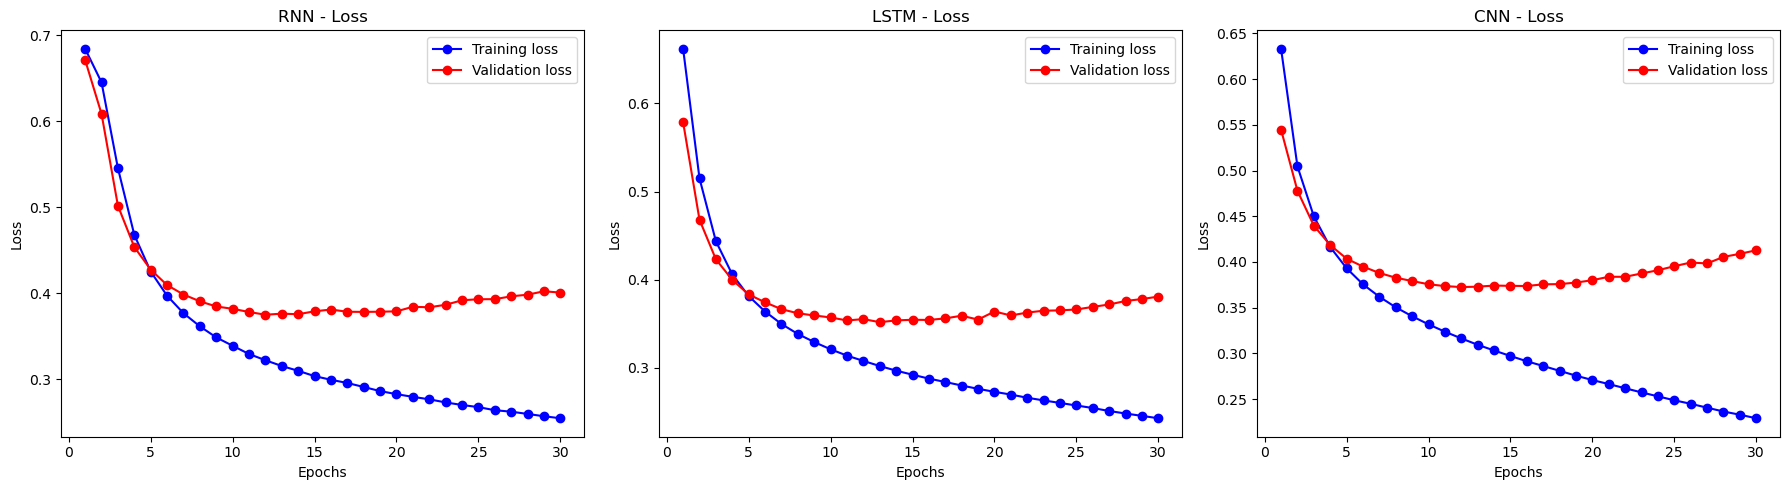

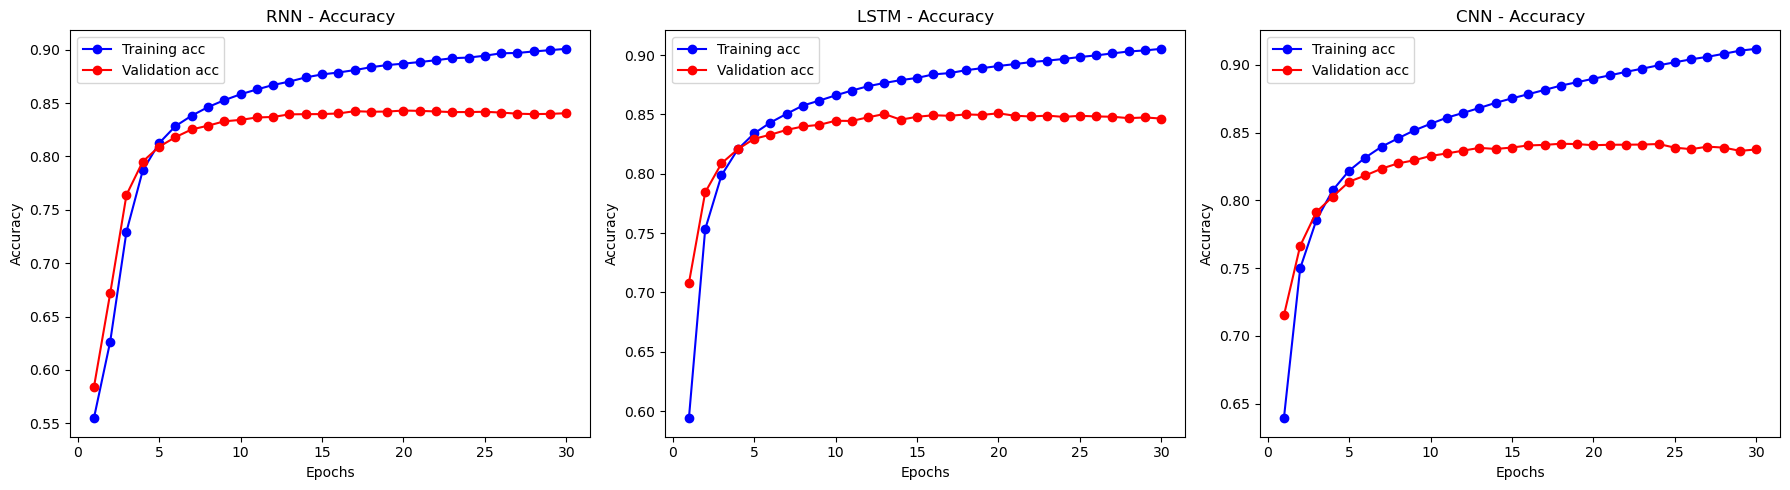

In [33]:
import matplotlib.pyplot as plt

epochs_range = range(1, 31)

# Loss 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_results = {
    'RNN': rnn_results,
    'LSTM': lstm_results,
    'CNN': cnn_results
}

for ax, (name, results) in zip(axes, models_results.items()):
    train_losses, val_losses, train_accs, val_accs = results
    ax.plot(epochs_range, train_losses, 'bo-', label='Training loss')
    ax.plot(epochs_range, val_losses, 'ro-', label='Validation loss')
    ax.set_title(f'{name} - Loss')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.show()

# Accuracy 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, results) in zip(axes, models_results.items()):
    train_losses, val_losses, train_accs, val_accs = results
    ax.plot(epochs_range, train_accs, 'bo-', label='Training acc')
    ax.plot(epochs_range, val_accs, 'ro-', label='Validation acc')
    ax.set_title(f'{name} - Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()

---
### Loss 그래프
- 세 모델 모두 Training Loss는 꾸준히 감소하나, Validation Loss는 10~13 epoch 이후 증가한다.
- Train Loss와 Val Loss의 격차가 epoch이 진행될수록 벌어지며, 이는 과적합을 의미한다.
- LSTM이 가장 빠르게 수렴하였고, CNN은 초기 Loss가 가장 낮았으나 후반부 격차가 가장 크다.

### Accuracy 그래프
- Training Accuracy는 세 모델 모두 90% 이상까지 상승하나, Validation Accuracy는 84% 부근에서 정체된다.
- LSTM의 Val Acc이 가장 높고 안정적이며, CNN은 후반부에서 Val Acc이 소폭 하락하는 경향을 보인다.
- 세 모델 모두 약 15 epoch 이후에는 Val Acc 개선이 거의 없으므로, early stopping 적용 시 15 epoch이 적절하다.

---

## STEP 7: 학습된 Embedding 레이어 분석

In [35]:
from gensim.models import KeyedVectors

# LSTM 모델에서 임베딩 가중치 추출
embedding_weights = lstm_model.embedding.weight.detach().numpy()

# gensim KeyedVectors로 변환
word_vectors = KeyedVectors(vector_size=word_vector_dim)
words = [index_to_word.get(i, f'<UNK_{i}>') for i in range(vocab_size)]
word_vectors.add_vectors(words, embedding_weights)

# 유사단어 확인
print("'영화'와 유사한 단어:")
print(word_vectors.most_similar('영화', topn=10))

print("\n'최고'와 유사한 단어:")
print(word_vectors.most_similar('최고', topn=10))

print("\n'별로'와 유사한 단어:")
print(word_vectors.most_similar('별로', topn=10))

'영화'와 유사한 단어:
[('버려서', 0.799674928188324), ('남여', 0.7944344282150269), ('철학', 0.7699036002159119), ('도망치', 0.7605968117713928), ('폰부스', 0.737524151802063), ('카메론디아즈', 0.7238041162490845), ('남발', 0.7158702611923218), ('쥬라기', 0.7089802026748657), ('겁나게', 0.7064169645309448), ('버렸', 0.7061634659767151)]

'최고'와 유사한 단어:
[('이끈', 0.8414536118507385), ('베스트셀러', 0.7700226306915283), ('놀라움', 0.7635918855667114), ('일품', 0.7490317821502686), ('어렷', 0.7459096312522888), ('겠다는', 0.7366272211074829), ('전투', 0.7215971946716309), ('고조', 0.7138553857803345), ('헛소리', 0.7121840715408325), ('브루스', 0.7061442136764526)]

'별로'와 유사한 단어:
[('살릴', 0.8056102395057678), ('비추', 0.7980717420578003), ('아까움', 0.7659843564033508), ('징기스칸', 0.7582581043243408), ('철철', 0.738814651966095), ('애초', 0.7277711629867554), ('이정진', 0.7261189818382263), ('퀴즈', 0.7229444980621338), ('글쎄', 0.7226207256317139), ('지겨움', 0.7177959680557251)]


---
### 유사단어 결과
- **'최고'**: '일품', '놀라움' 등 긍정적 단어가 일부 포함되나, '헛소리', '전투' 등 관련 없는 단어도 섞여 있다.
- **'별로'**: '비추', '지겨움', '글쎄' 등 부정적 단어가 포함되어 감성 방향은 어느 정도 학습된 것으로 보인다.
- **'영화'**: 유의미한 유사 단어가 거의 없으며, 감성과 무관한 단어들이 나타난다.

### 분석
- 감성분류 목적으로 학습된 임베딩이라 단어의 의미적 유사성보다는 감성 방향(긍/부정) 위주로 학습된 경향이 있다.
- 임베딩 차원이 16으로 작고, 학습 데이터만으로 훈련했기 때문에 단어 간 의미 관계를 정밀하게 표현하기 어렵다.
- 이후 Word2Vec 사전학습 임베딩과 비교하여 의미적 유사도 품질 차이를 확인한다.

---

## STEP 8: 한국어 Word2Vec 임베딩 활용하여 성능 개선

### 1) gensim Word2Vec 자체학습
네이버 영화 리뷰 데이터로 Word2Vec을 직접 학습하고 유사단어를 확인한다.

In [37]:
# 학습 데이터 준비
from gensim.models import Word2Vec

# 패딩 전 원본 데이터를 단어로 변환 (X_train이 패딩 전 원본인지 확인)
train_sentences = []
for sentence in train_data['document'].dropna():
    tokens = tokenizer.morphs(sentence)
    tokens = [word for word in tokens if word not in stopwords]
    train_sentences.append(tokens)

print(f'학습 문장 수: {len(train_sentences)}')
print(f'샘플: {train_sentences[0]}')

학습 문장 수: 146182
샘플: ['아', '더', '빙', '.', '.', '진짜', '짜증', '나', '네요', '목소리']


In [42]:
# Word2Vec 자체 학습
w2v_custom = Word2Vec(
    sentences=train_sentences, 
    vector_size=100, 
    window=5, 
    min_count=5, 
    workers=4, 
    sg=0
)

print(f'학습된 단어 수: {len(w2v_custom.wv)}')

학습된 단어 수: 16022


In [43]:
print("=== 자체학습 Word2Vec ===")
print("'영화':", w2v_custom.wv.most_similar('영화', topn=5))
print("'최고':", w2v_custom.wv.most_similar('최고', topn=5))
print("'별로':", w2v_custom.wv.most_similar('별로', topn=5))

=== 자체학습 Word2Vec ===
'영화': [('작품', 0.5843018889427185), ('드라마', 0.5724298357963562), ('애니메이션', 0.565122663974762), ('애니', 0.5215656161308289), ('만화', 0.5062500834465027)]
'최고': [('단연', 0.6932545304298401), ('으뜸', 0.6785012483596802), ('최강', 0.6755807399749756), ('명품', 0.6319571733474731), ('레전드', 0.6304534673690796)]
'별로': [('별루', 0.7643020749092102), ('무섭', 0.5832079648971558), ('솔직히', 0.5811440944671631), ('그닥', 0.572028398513794), ('뻔하', 0.5193861126899719)]


---

### 2) 사전학습 Word2Vec 로드 및 분석
한국어 사전학습 Word2Vec 모델을 로드하고 유사단어를 확인하여 자체학습 임베딩과 비교한다.

# 모델 로드
word2vec_pretrained = Word2Vec.load(os.getenv("HOME") + '/work/AIFFEL_quest_rs/Exploration/Ex05/data/word2vec_ko.model')
print(f'단어 수: {len(word2vec_pretrained.wv)}')
print(f'벡터 차원: {word2vec_pretrained.wv.vector_size}')

In [41]:
print("=== 사전학습 Word2Vec ===")
print("'영화':", word2vec_pretrained.wv.most_similar('영화', topn=5))
print("'최고':", word2vec_pretrained.wv.most_similar('최고', topn=5))
print("'별로':", word2vec_pretrained.wv.most_similar('별로', topn=5))

=== 사전학습 Word2Vec ===
'영화': [('드라마', 0.8418774008750916), ('뮤지컬', 0.7775140404701233), ('코미디', 0.7489107251167297), ('다큐멘터리', 0.7401294708251953), ('헐리우드', 0.7397844195365906)]
'최고': [('역대', 0.6544249653816223), ('최다', 0.6139797568321228), ('최악', 0.6104292273521423), ('최대', 0.6001774072647095), ('최저', 0.5936914682388306)]
'별로': [('전혀', 0.6421527862548828), ('그다지', 0.6234328746795654), ('꽤', 0.6035930514335632), ('확실히', 0.5738269090652466), ('딱히', 0.5515185594558716)]


---
### 자체학습 vs 사전학습 Word2Vec 비교

| 단어 | 자체학습 (네이버 리뷰) | 사전학습 (한국어 범용) |
|------|----------------------|---------------------|
| 영화 | 작품, 드라마, 애니메이션 | 드라마, 뮤지컬, 코미디, 다큐멘터리 |
| 최고 | 단연, 으뜸, 최강, 명품, 레전드 | 역대, 최다, 최악, 최대, 최저 |
| 별로 | 별루, 무섭, 그닥, 뻔하 | 전혀, 그다지, 꽤, 딱히 |

### 분석
- **사전학습 모델**은 대규모 한국어 데이터로 학습되어 유사도 점수가 높고, 일반적인 의미 관계를 잘 포착한다. '영화'에 대해 다양한 장르를 정확히 연결한다.
- **자체학습 모델**은 영화 리뷰 도메인에 특화되어 '최고'→'레전드','명품' 등 감성 표현을 더 잘 반영한다. 반면 사전학습은 '최고'→'최악','최저' 등 의미보다 형태적 유사성을 보인다.
- 감성분류 태스크에서는 자체학습 임베딩이 도메인 특성을 더 잘 반영하므로 유리할 수 있으나, 사전학습 임베딩은 범용적 단어 관계가 풍부하여 일반화 성능이 기대된다.

---

### STEP 10: Word2Vec 임베딩을 활용한 모델 학습
자체학습 Word2Vec과 사전학습 Word2Vec 임베딩을 각각 적용하여 성능을 비교한다.

### 1) 임베딩 매트릭스 생성

In [45]:
### 자체 학습 임베딩 매트릭스 생성
word_vector_dim = 100

# 자체학습 Word2Vec 임베딩 매트릭스
embedding_matrix_custom = np.random.rand(vocab_size, word_vector_dim)
for i in range(4, vocab_size):
    if index_to_word[i] in w2v_custom.wv:
        embedding_matrix_custom[i] = w2v_custom.wv[index_to_word[i]]

count = sum(1 for i in range(4, vocab_size) if index_to_word[i] in w2v_custom.wv)
print(f'자체학습 임베딩 매칭 단어 수: {count}/{vocab_size-4}')

자체학습 임베딩 매칭 단어 수: 9996/9996


In [46]:
### 사전 학습 임베딩 매트릭스 생성
embedding_matrix_pretrained = np.random.rand(vocab_size, word_vector_dim)
for i in range(4, vocab_size):
    if index_to_word[i] in word2vec_pretrained.wv:
        embedding_matrix_pretrained[i] = word2vec_pretrained.wv[index_to_word[i]]

count = sum(1 for i in range(4, vocab_size) if index_to_word[i] in word2vec_pretrained.wv)
print(f'사전학습 임베딩 매칭 단어 수: {count}/{vocab_size-4}')

사전학습 임베딩 매칭 단어 수: 9457/9996


### 2) 모델 정의(3개: RNN, LSTM, 1D-CNN)

In [47]:
class W2V_RNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix):
        super(W2V_RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.rnn = nn.RNN(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, hn = self.rnn(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

class W2V_LSTMModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix):
        super(W2V_LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

class W2V_CNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix):
        super(W2V_CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

### 3) 학습 

In [48]:
print("=== 자체학습 W2V + RNN ===")
w2v_rnn_custom = W2V_RNNModel(vocab_size, word_vector_dim, embedding_matrix_custom)
w2v_rnn_custom_results = train_model(w2v_rnn_custom, epochs=15)

print("\n=== 자체학습 W2V + LSTM ===")
w2v_lstm_custom = W2V_LSTMModel(vocab_size, word_vector_dim, embedding_matrix_custom)
w2v_lstm_custom_results = train_model(w2v_lstm_custom, epochs=15)

print("\n=== 자체학습 W2V + CNN ===")
w2v_cnn_custom = W2V_CNNModel(vocab_size, word_vector_dim, embedding_matrix_custom)
w2v_cnn_custom_results = train_model(w2v_cnn_custom, epochs=15)

=== 자체학습 W2V + RNN ===
Epoch 1/15 - Train Loss: 0.6236, Train Acc: 0.6529 - Val Loss: 0.5243, Val Acc: 0.7520
Epoch 2/15 - Train Loss: 0.4605, Train Acc: 0.7938 - Val Loss: 0.4333, Val Acc: 0.8126
Epoch 3/15 - Train Loss: 0.3916, Train Acc: 0.8359 - Val Loss: 0.4141, Val Acc: 0.8213
Epoch 4/15 - Train Loss: 0.3641, Train Acc: 0.8509 - Val Loss: 0.4054, Val Acc: 0.8305
Epoch 5/15 - Train Loss: 0.3412, Train Acc: 0.8627 - Val Loss: 0.4007, Val Acc: 0.8334
Epoch 6/15 - Train Loss: 0.3291, Train Acc: 0.8690 - Val Loss: 0.4024, Val Acc: 0.8329
Epoch 7/15 - Train Loss: 0.3168, Train Acc: 0.8754 - Val Loss: 0.4044, Val Acc: 0.8357
Epoch 8/15 - Train Loss: 0.3066, Train Acc: 0.8804 - Val Loss: 0.4016, Val Acc: 0.8382
Epoch 9/15 - Train Loss: 0.2975, Train Acc: 0.8852 - Val Loss: 0.4062, Val Acc: 0.8367
Epoch 10/15 - Train Loss: 0.2959, Train Acc: 0.8851 - Val Loss: 0.4067, Val Acc: 0.8351
Epoch 11/15 - Train Loss: 0.2863, Train Acc: 0.8904 - Val Loss: 0.4084, Val Acc: 0.8358
Epoch 12/15 - Trai

In [49]:
print("=== 사전학습 W2V + RNN ===")
w2v_rnn_pretrained = W2V_RNNModel(vocab_size, word_vector_dim, embedding_matrix_pretrained)
w2v_rnn_pretrained_results = train_model(w2v_rnn_pretrained, epochs=15)

print("\n=== 사전학습 W2V + LSTM ===")
w2v_lstm_pretrained = W2V_LSTMModel(vocab_size, word_vector_dim, embedding_matrix_pretrained)
w2v_lstm_pretrained_results = train_model(w2v_lstm_pretrained, epochs=15)

print("\n=== 사전학습 W2V + CNN ===")
w2v_cnn_pretrained = W2V_CNNModel(vocab_size, word_vector_dim, embedding_matrix_pretrained)
w2v_cnn_pretrained_results = train_model(w2v_cnn_pretrained, epochs=15)

=== 사전학습 W2V + RNN ===
Epoch 1/15 - Train Loss: 0.6673, Train Acc: 0.5841 - Val Loss: 0.6419, Val Acc: 0.6361
Epoch 2/15 - Train Loss: 0.6082, Train Acc: 0.6719 - Val Loss: 0.5770, Val Acc: 0.7047
Epoch 3/15 - Train Loss: 0.5403, Train Acc: 0.7326 - Val Loss: 0.5259, Val Acc: 0.7440
Epoch 4/15 - Train Loss: 0.4925, Train Acc: 0.7686 - Val Loss: 0.4965, Val Acc: 0.7647
Epoch 5/15 - Train Loss: 0.4586, Train Acc: 0.7906 - Val Loss: 0.4820, Val Acc: 0.7743
Epoch 6/15 - Train Loss: 0.4340, Train Acc: 0.8049 - Val Loss: 0.4709, Val Acc: 0.7856
Epoch 7/15 - Train Loss: 0.4141, Train Acc: 0.8167 - Val Loss: 0.4657, Val Acc: 0.7904
Epoch 8/15 - Train Loss: 0.3975, Train Acc: 0.8258 - Val Loss: 0.4547, Val Acc: 0.7984
Epoch 9/15 - Train Loss: 0.3826, Train Acc: 0.8347 - Val Loss: 0.4574, Val Acc: 0.7992
Epoch 10/15 - Train Loss: 0.3706, Train Acc: 0.8422 - Val Loss: 0.4531, Val Acc: 0.8034
Epoch 11/15 - Train Loss: 0.3611, Train Acc: 0.8459 - Val Loss: 0.4459, Val Acc: 0.8060
Epoch 12/15 - Trai

---
기존 모델에서 성능 향상을 위해 hidden size를 확대하였다.

| 파라미터 | 기존 | 변경 |
|---------|------|------|
| Hidden Size (RNN/LSTM) | 8 | 64 |
| Conv1d out_channels (CNN) | 16 | 64 |
| FC1 | Linear(8, 8) | Linear(64, 32) |
| FC2 | Linear(8, 1) | Linear(32, 1) |
| Embedding 차원 | 16 (랜덤 초기화) | 100 (Word2Vec) |

기존 모델은 hidden size가 8로 너무 작아 표현력이 부족했으며, Word2Vec 임베딩(100차원)의 정보를 충분히 활용하지 못했다. Hidden size를 64로 확대하여 모델의 표현력을 높였다.

---

In [53]:
# 3개 모델 전체 수정 버전
class W2V_RNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix):
        super(W2V_RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.rnn = nn.RNN(word_vector_dim, 64, batch_first=True)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, hn = self.rnn(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

class W2V_LSTMModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix):
        super(W2V_LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.lstm = nn.LSTM(word_vector_dim, 64, batch_first=True)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

class W2V_CNNModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix):
        super(W2V_CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.conv1 = nn.Conv1d(word_vector_dim, 64, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [54]:
print("=== 자체학습 W2V + RNN ===")
w2v_rnn_custom = W2V_RNNModel(vocab_size, word_vector_dim, embedding_matrix_custom)
w2v_rnn_custom_results = train_model(w2v_rnn_custom, epochs=5)

print("\n=== 자체학습 W2V + LSTM ===")
w2v_lstm_custom = W2V_LSTMModel(vocab_size, word_vector_dim, embedding_matrix_custom)
w2v_lstm_custom_results = train_model(w2v_lstm_custom, epochs=5)

print("\n=== 자체학습 W2V + CNN ===")
w2v_cnn_custom = W2V_CNNModel(vocab_size, word_vector_dim, embedding_matrix_custom)
w2v_cnn_custom_results = train_model(w2v_cnn_custom, epochs=5)

print("=== 사전학습 W2V + RNN ===")
w2v_rnn_pretrained = W2V_RNNModel(vocab_size, word_vector_dim, embedding_matrix_pretrained)
w2v_rnn_pretrained_results = train_model(w2v_rnn_pretrained, epochs=5)

print("\n=== 사전학습 W2V + LSTM ===")
w2v_lstm_pretrained = W2V_LSTMModel(vocab_size, word_vector_dim, embedding_matrix_pretrained)
w2v_lstm_pretrained_results = train_model(w2v_lstm_pretrained, epochs=5)

print("\n=== 사전학습 W2V + CNN ===")
w2v_cnn_pretrained = W2V_CNNModel(vocab_size, word_vector_dim, embedding_matrix_pretrained)
w2v_cnn_pretrained_results = train_model(w2v_cnn_pretrained, epochs=5)

=== 자체학습 W2V + RNN ===
Epoch 1/5 - Train Loss: 0.4717, Train Acc: 0.7806 - Val Loss: 0.4062, Val Acc: 0.8257
Epoch 2/5 - Train Loss: 0.3808, Train Acc: 0.8357 - Val Loss: 0.3655, Val Acc: 0.8457
Epoch 3/5 - Train Loss: 0.3352, Train Acc: 0.8587 - Val Loss: 0.3476, Val Acc: 0.8481
Epoch 4/5 - Train Loss: 0.3084, Train Acc: 0.8725 - Val Loss: 0.3398, Val Acc: 0.8537
Epoch 5/5 - Train Loss: 0.2914, Train Acc: 0.8801 - Val Loss: 0.3427, Val Acc: 0.8515

=== 자체학습 W2V + LSTM ===
Epoch 1/5 - Train Loss: 0.4330, Train Acc: 0.7998 - Val Loss: 0.3551, Val Acc: 0.8419
Epoch 2/5 - Train Loss: 0.3298, Train Acc: 0.8564 - Val Loss: 0.3236, Val Acc: 0.8589
Epoch 3/5 - Train Loss: 0.2919, Train Acc: 0.8755 - Val Loss: 0.3145, Val Acc: 0.8650
Epoch 4/5 - Train Loss: 0.2659, Train Acc: 0.8889 - Val Loss: 0.3161, Val Acc: 0.8659
Epoch 5/5 - Train Loss: 0.2463, Train Acc: 0.8983 - Val Loss: 0.3272, Val Acc: 0.8658

=== 자체학습 W2V + CNN ===
Epoch 1/5 - Train Loss: 0.4201, Train Acc: 0.8075 - Val Loss: 0.3612

### 4) 평가

In [55]:
print("=== 자체학습 Word2Vec ===")
print("RNN:"); evaluate_model(w2v_rnn_custom, test_loader)
print("LSTM:"); evaluate_model(w2v_lstm_custom, test_loader)
print("CNN:"); evaluate_model(w2v_cnn_custom, test_loader)

print("\n=== 사전학습 Word2Vec ===")
print("RNN:"); evaluate_model(w2v_rnn_pretrained, test_loader)
print("LSTM:"); evaluate_model(w2v_lstm_pretrained, test_loader)
print("CNN:"); evaluate_model(w2v_cnn_pretrained, test_loader)

=== 자체학습 Word2Vec ===
RNN:
Test Accuracy: 0.8526
LSTM:
Test Accuracy: 0.8647
CNN:
Test Accuracy: 0.8573

=== 사전학습 Word2Vec ===
RNN:
Test Accuracy: 0.8447
LSTM:
Test Accuracy: 0.8571
CNN:
Test Accuracy: 0.8460


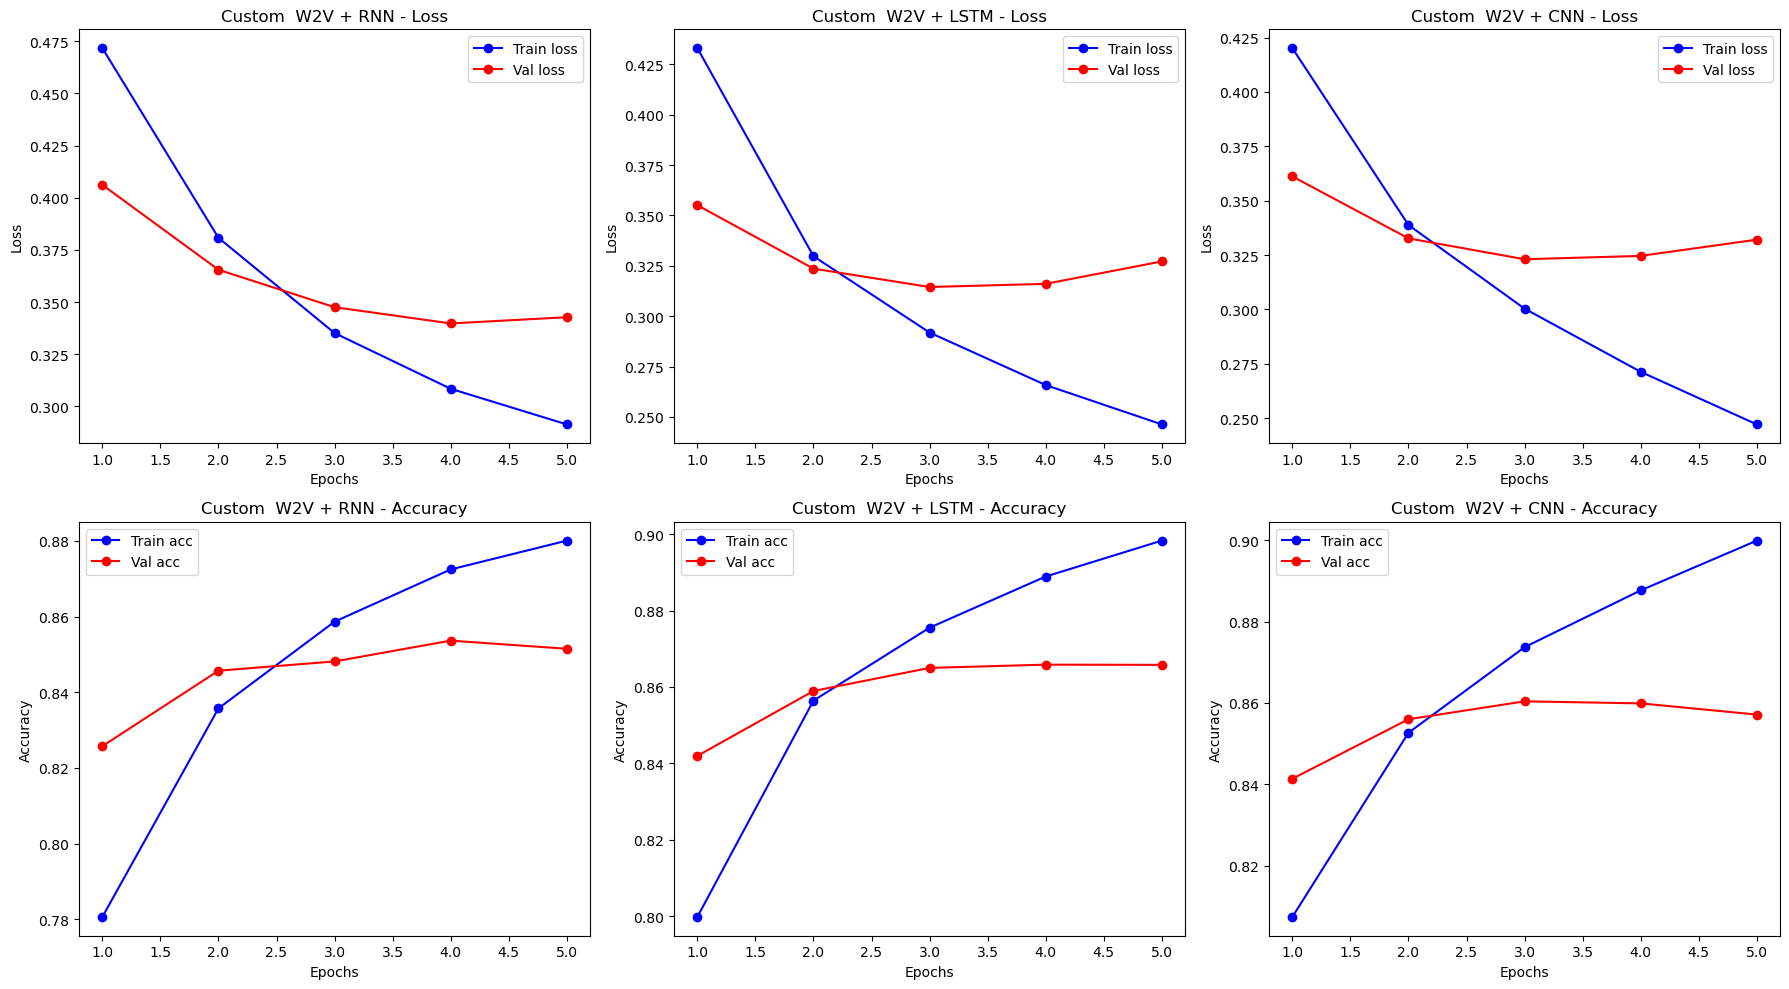

In [61]:
# 자체 학습 그래프
epochs_range = range(1, 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

custom_models = {
    'RNN': w2v_rnn_custom_results,
    'LSTM': w2v_lstm_custom_results,
    'CNN': w2v_cnn_custom_results
}

for idx, (name, results) in enumerate(custom_models.items()):
    train_losses, val_losses, train_accs, val_accs = results
    axes[0][idx].plot(epochs_range, train_losses, 'bo-', label='Train loss')
    axes[0][idx].plot(epochs_range, val_losses, 'ro-', label='Val loss')
    axes[0][idx].set_title(f'Custom  W2V + {name} - Loss')
    axes[0][idx].set_xlabel('Epochs')
    axes[0][idx].set_ylabel('Loss')
    axes[0][idx].legend()

    axes[1][idx].plot(epochs_range, train_accs, 'bo-', label='Train acc')
    axes[1][idx].plot(epochs_range, val_accs, 'ro-', label='Val acc')
    axes[1][idx].set_title(f'Custom  W2V + {name} - Accuracy')
    axes[1][idx].set_xlabel('Epochs')
    axes[1][idx].set_ylabel('Accuracy')
    axes[1][idx].legend()

plt.tight_layout()
plt.show()

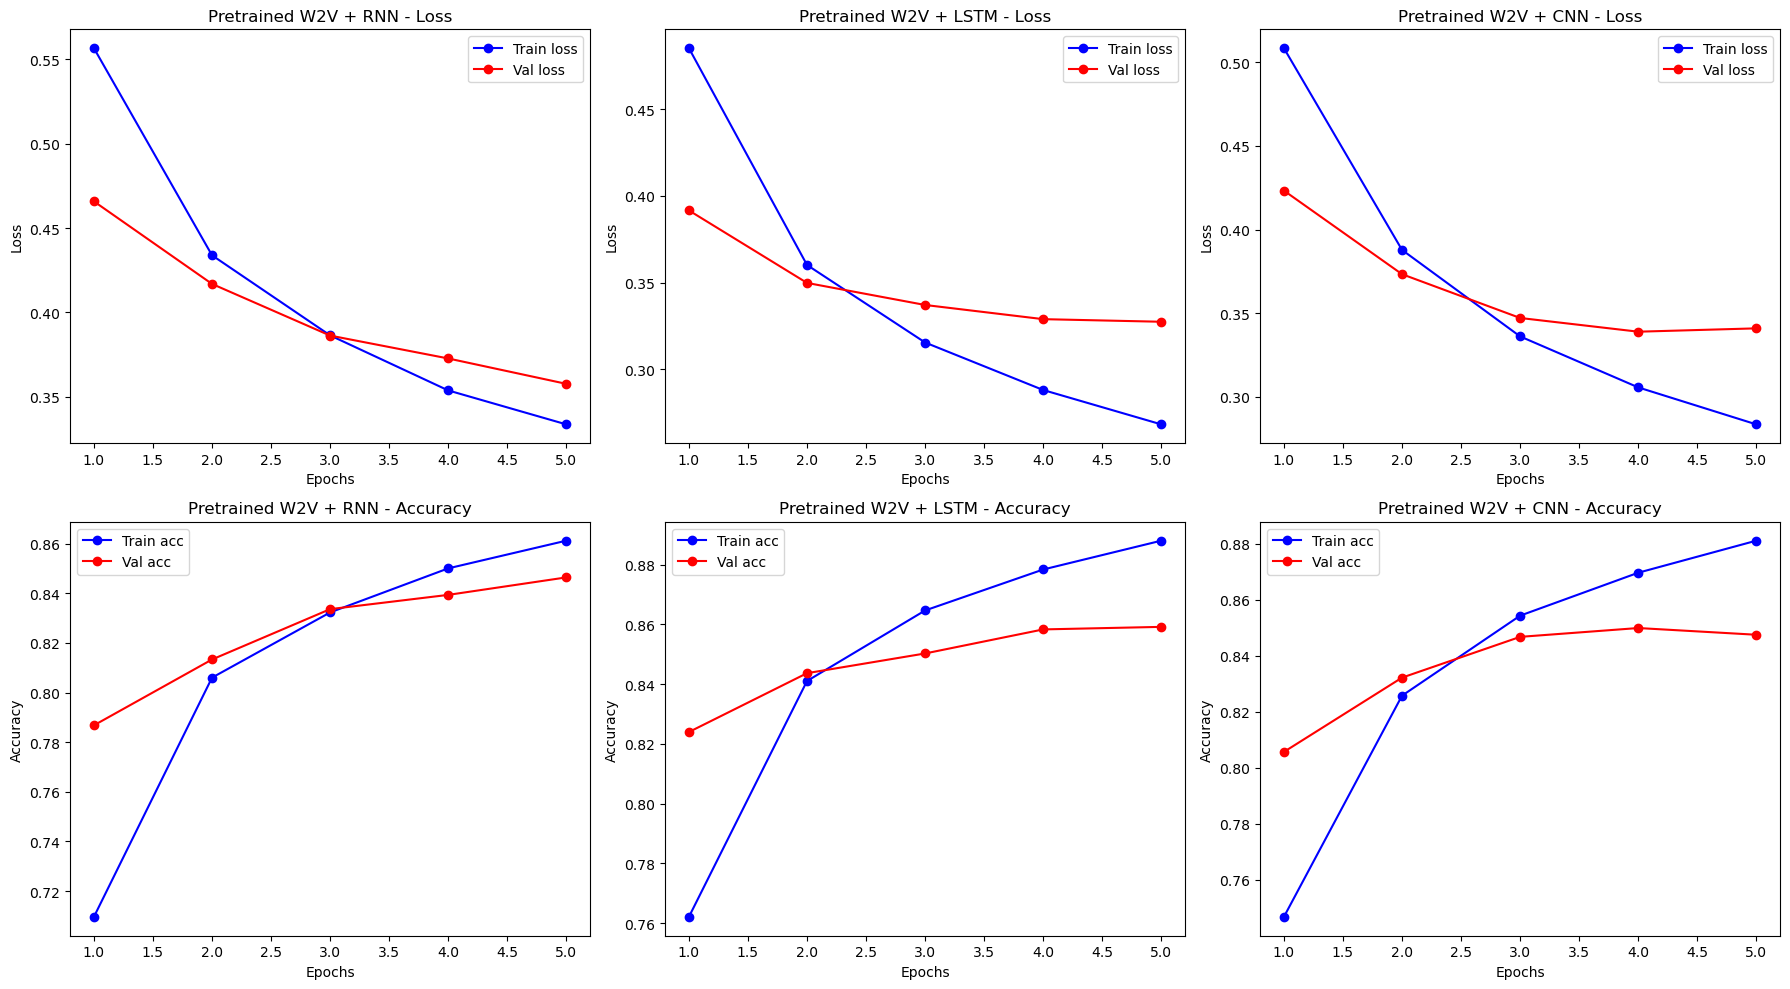

In [62]:
# 사전 학습 그래프
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pretrained_models = {
    'RNN': w2v_rnn_pretrained_results,
    'LSTM': w2v_lstm_pretrained_results,
    'CNN': w2v_cnn_pretrained_results
}

for idx, (name, results) in enumerate(pretrained_models.items()):
    train_losses, val_losses, train_accs, val_accs = results
    axes[0][idx].plot(epochs_range, train_losses, 'bo-', label='Train loss')
    axes[0][idx].plot(epochs_range, val_losses, 'ro-', label='Val loss')
    axes[0][idx].set_title(f'Pretrained W2V + {name} - Loss')
    axes[0][idx].set_xlabel('Epochs')
    axes[0][idx].set_ylabel('Loss')
    axes[0][idx].legend()

    axes[1][idx].plot(epochs_range, train_accs, 'bo-', label='Train acc')
    axes[1][idx].plot(epochs_range, val_accs, 'ro-', label='Val acc')
    axes[1][idx].set_title(f'Pretrained W2V + {name} - Accuracy')
    axes[1][idx].set_xlabel('Epochs')
    axes[1][idx].set_ylabel('Accuracy')
    axes[1][idx].legend()

plt.tight_layout()
plt.show()

## Word2Vec 임베딩 적용 결과 (Hidden Size 64, Epoch 5)

### 자체학습 Word2Vec
| 모델 | Val Acc (Best) | Test Acc |
|------|---------------|----------|
| RNN | 85.37% | 85.26% |
| LSTM | 86.59% | **86.47%** |
| CNN | 86.04% | 85.73% |

### 사전학습 Word2Vec
| 모델 | Val Acc (Best) | Test Acc |
|------|---------------|----------|
| RNN | 84.65% | 84.47% |
| LSTM | 85.91% | 85.71% |
| CNN | 84.98% | 84.60% |

### 분석
- **자체학습 Word2Vec + LSTM**이 Test Acc 86.47%로 최고 성능을 달성하여 목표 85%를 초과하였다.
- 자체학습 임베딩이 사전학습 임베딩보다 전반적으로 1~2% 높은 성능을 보인다. 이는 영화 리뷰 도메인에 특화된 임베딩이 범용 임베딩보다 감성분류에 더 효과적임을 의미한다.
- Hidden size를 8→64로 확대한 것이 성능 향상에 기여하였다.
- 세 모델 중 LSTM이 가장 좋은 성능을 보였으며, 이는 리뷰 텍스트의 장기 의존성을 잘 학습하기 때문으로 판단된다.

## 회고

### 프로젝트 요약
네이버 영화 리뷰 데이터를 활용하여 감성분류 모델을 구현하였다. RNN, LSTM, 1D CNN 3가지 모델을 구현하고, gensim Word2Vec 자체학습 및 사전학습 임베딩을 비교 분석하였다.

### 배운 점
- 랜덤 초기화 임베딩(84%)보다 Word2Vec 임베딩(86%)이 확실히 성능 향상에 기여하였다.
- 자체학습 임베딩이 사전학습 임베딩보다 도메인 특화 태스크에서 더 좋은 성능을 보였다.
- Hidden size 등 하이퍼파라미터 조정이 성능에 큰 영향을 미친다는 것을 확인하였다.
- 과적합 모니터링을 통해 적절한 epoch 설정의 중요성을 배웠다.